<a href="https://colab.research.google.com/github/lloydakresi/ml_journey/blob/main/My_Personal_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch

In [ ]:
X = torch.randn((32, 8, 2))
Y = torch.randn((32, ))

In [ ]:
torch.manual_seed(42)

In [ ]:
class Linear():
  def __init__(self, input_dim, output_dim, set_bias=False):
    self.input_dim = input_dim
    self.output_dim = output_dim
    self.weights = torch.randn((input_dim, output_dim))
    self.bias = torch.ones((output_dim)) if set_bias else None

  def __call__(self, x):
    self.out = x @ self.weights + self.bias if self.bias is not None else x @ self.weights
    return self.out

  def __repr__(self):
    return f"Linear(input_dim={self.input_dim}, output_dim={self.output_dim})"

  def parameters(self):
    return [self.weights] + ([] if self.bias is None else [self.bias])


class Tanh():
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def __repr__(self):
    return f"Tanh()"

  def parameters(self):
    return []


class ConsecutiveFlatten():
  def __init__(self, n):
    self.n = n

  def __repr__(self):
    return f"ConsecutiveFlatten(n={self.n})"

  def __call__(self, x):

    B, R, C = x.shape
    flattened = x.view(B, R//self.n, C*self.n)

    if flattened.shape[1] == 1:
      flattened = flattened.squeeze(1)


    return flattened

  def parameters(self):
    return []



class Sequential():
  def __init__(self, layers):
    self.layers = layers
    self.params = []

  def __repr__(self):
    s = []
    for layer in self.layers:
      s.append(layer)
    return f"Sequential(\n{s}\n)"

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return x

  def parameters(self):
    self.params = [p for layer in self.layers for p in layer.parameters()]
    return self.params


In [ ]:
class BasicRNN():
  def __init__(self, n_features, n_neurons, state=None):
    self.hidden = n_neurons
    self.input = n_features
    self.W_x = torch.randn((n_features, n_neurons))
    self.W_h = torch.randn((n_neurons, n_neurons))
    self.b_h = torch.zeros((n_neurons))
    self.state = state

  def __call__(self, x):
    if self.state is None:
      self.state = torch.zeros((x.shape[1], self.hidden))

    output = []
    for input in x:
      self.state = torch.tanh(
          input @ self.W_x +
          self.state @ self.W_h +
          self.b_h
      )
      output.append(self.state)

    return output, self.state

  def __repr__(self):
    return f"BasicRNN(n_inputs={self.input}, n_output={self.hidden})"

  def parameters(self):
    return [self.W_x, self.W_h, self.b_h]








In [ ]:
X = torch.randn((10, 32, 4))
Y = torch.randn((32, 1))

In [ ]:
hidden = 20
rnn = BasicRNN(X.shape[-1], hidden)
linear = Linear(hidden, 1, True)
rnn

BasicRNN(n_inputs=2, n_output=20)

In [ ]:
import torch.nn.functional as F

model_params = rnn.parameters() + linear.parameters()
for p in model_params:
  p.requires_grad = True

epochs = 100
for i in range(epochs):
  #forward pass
  outputs, state = rnn(X)
  logits = linear(state)
  #logits = logits.squeeze(-1)
  loss = F.mse_loss(logits, Y)


  #backward pass
  for p in model_params:
    p.grad = None

  loss.backward(retain_graph=True)

  lr = 0.01
  for p in model_params:
    p.data += -lr * p.grad

print(loss.item())



/tmp/ipykernel_17847/2197095341.py:13: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(logits, Y)


0.9296449422836304


In [ ]:
t  = torch.linspace(0, 10, 2000)
Y = torch.sin(t)


In [ ]:
seq_len = 50
i = Y.shape[0] - seq_len
X_seq = []
Y_seq = []
for idx in range(i):
  X_seq.append(Y[idx: idx+seq_len])
  Y_seq.append(Y[idx+seq_len])
print(len(X_seq))
#produce dataset of shape = sequence length * num_sequences
X_d = torch.stack(X_seq, dim=1)
time_step = X_d.shape[0]
batch_size = X_d.shape[1]
X_final = X_d.view(time_step, batch_size, 1)
print(X_final.shape)


Y_dataset = torch.stack(Y_seq)
Y_final = Y_dataset.view(Y_dataset.shape[0], 1)
print(Y_final.shape)


1950
torch.Size([50, 1950, 1])
torch.Size([1950, 1])


In [ ]:
X_tr = X_final[:, :1500, :]
Y_tr = Y_final[:1500, :]

X_dev = X_final[:, 1500:1725, :]
Y_dev = Y_final[1500:1725, :]

X_test = X_final[:, 1725:1950, :]
Y_test = Y_final[1725:1950, :]

In [ ]:
hidden = 5
input = X_tr.shape[-1]
rnn = BasicRNN(input, hidden)
linear = Linear(hidden, 1, True)
linear

Linear(input_dim=5, output_dim=1)

In [ ]:
from math import nan
epochs = 100
b = 32
model_params = rnn.parameters() + linear.parameters()
#linear.parameters()[0]
for p in model_params:
  p.requires_grad = True

lossi = []
lri = []
lre = torch.linspace(-3, 0, 200)
lrs = 10**lre

for i in range(lrs.shape[0]):
  b_ix = torch.randint(low=0, high=X_tr.shape[1], size=(b, ))
  X_b = X_tr[:, b_ix, :]
  Y_b = Y_tr[b_ix, :]
  #forward pass
  state, h_s = rnn(X_b)
  logits = linear(h_s)
  loss = F.mse_loss(logits, Y_b)


  #backward pass
  for p in model_params:
    p.grad = None

  loss.backward(retain_graph=True)

  #update params
  lr = 0.01
  for p in model_params:
    p.data += -lrs[i] * p.grad
  if loss.item() == nan:
    break
  else:
    lossi.append(loss.item())
    lri.append(lrs[i])




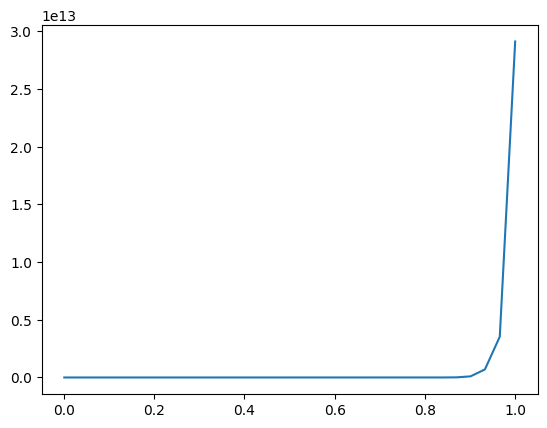

In [ ]:
import matplotlib.pyplot as plt
plt.plot(lrs, lossi)

In [ ]:
n = 2
n_features = X.shape[-1]
n_hidden = 20
layers = [ConsecutiveFlatten(n), Linear(n_features*n, n_hidden), Tanh(),
          ConsecutiveFlatten(n), Linear(n_hidden*n, n_hidden), Tanh(),
          ConsecutiveFlatten(n), Linear(n_hidden*n, n_hidden), Tanh(),
          Linear(n_hidden, 1)
          ]
model = Sequential(layers)
model.layers[-1].weights *= 0.1

for p in model.parameters():
  p.requires_grad = True

In [ ]:

epochs = 100
for i in range(epochs):
  #forward pass
  logits = model(X).squeeze(1)
  loss = F.mse_loss(logits, Y)


  #backward pass
  for p in model.parameters():
    p.grad = None

  loss.backward()

  lr = 0.1
  for p in model.parameters():
    p.data += -lr * p.grad

print(loss.item())




0.0026888353750109673


In [ ]:
X = torch.randn((32, 4))
Y = torch.randn((32, ))

In [ ]:
n_features = 4
n_hidden = 20
mlp_layers = [
    Linear(n_features, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden//2), Tanh(),
    Linear(n_hidden//2, 1),
]

mlp = Sequential(mlp_layers)
mlp.layers[-1].weights *= 0.1

for p in mlp.parameters():
  p.requires_grad = True

mlp

Sequential(
[Linear(input_dim=4, output_dim=20), Tanh(), Linear(input_dim=20, output_dim=10), Tanh(), Linear(input_dim=10, output_dim=1)]
)

In [ ]:
for i in range(epochs):
  logits = mlp(X)
  logits = logits.squeeze(1)
  loss = F.mse_loss(logits, Y)

  for p in mlp.parameters():
    p.grad = None
  loss.backward()

  lr = 0.35
  for p in mlp.parameters():
    p.data += -lr * p.grad


loss.item()

0.010077370330691338

In [ ]:
class LSTM():
  def __init__(self, n_hidden, n_in):
    self.n_hidden = n_hidden
    self.n_in = n_in

  def __call__(self, x):
    self.h_x = torch.zeros((x.shape[-2], self.n_hidden))
    self.in_x = torch.concat(self.h_x, x, dim=-1)
    #forget gate
    self.W_f = torch.randn((self.in_x.shape[-1], n_hidden))
    self.b_f = torch.zeros(x.shape[-2],)
    self.f_t = torch.sigmoid(self.in_x @ self.W_f + self.b_f)
    self.c = torch.ones_like(self.f_t)
    self.c *= self.f_t

    #input gate
    self.W_i = torch.randn((self.in_x.shape[-1], n_hidden))
    self.b_i = torch.zeros(x.shape[-2],)
    self.i_t = torch.sigmoid(self.W_i @ self.in_x + self.b_i)
    self.W_c = torch.randn((self.in_x.shape[-1], n_hidden))
    self.b_c = torch.zeros(x.shape[-2],)
    self.c_t = torch.tanh(self.W_c @ self.in_x + self.b_c)
    self.i_prod = self.i_t * self.c_t
    self.c += self.i_prod

    #output gate
    self.W_o = torch.randn((self.in_x.shape[-1], n_hidden))
    self.b_o = torch.zeros(x.shape[-2],)
    self.o_t = torch.sigmoid(self.W_o @ self.in_x + self.b_o)
    self.ogo = torch.tanh(self.c) * self.o_t
    self.h_x = self.ogo

    return self.c, self.h_x

